# Bitcoin Price Prediction

This notebook is looking closely on predicting whether the closing price 30 minutes ahead is higher than the current close price. This is done based on datasets attached and 3 different ML or DL models. This notebook is for training the dataset and giving the results. There is also a second part to this notebook and that is a report with the implementation and evaluation.

### This notebook is divided into 4 parts:
- Data loading and pre-processing
- Feature and label creation
- Model definitions and training loops
- Evaluation metrics and plots

### Dataset Description
- open_time: opening timestamp in milliseconds
- open: opening price
- high: highest price during the interval
- low: lowest price during the interval
- close: closing price
- volume: trading volume
- close_time: closing timestamp in milliseconds

### Data Split
- training ~ 527,000 rows
- validation ~ 44,000 rows
- test ~ 128,000 rows

## PART A: Data loading and pre-processing

In [1]:
import os
import zipfile
import glob
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

import xgboost as xgb



In [2]:
# define paths
data_dir = "./BTCUSDT-1m"
train_path = os.path.join(data_dir, "training")
val_path   = os.path.join(data_dir, "validation")
test_path  = os.path.join(data_dir, "test")

In [3]:
# load data

def load_split(split_path):
    df_list = []
    for file in sorted(os.listdir(split_path)):
        if file.endswith(".csv"):
            df = pd.read_csv(os.path.join(split_path, file))
            df_list.append(df)
    combined = pd.concat(df_list, ignore_index=True)
    return combined

df_train = load_split(train_path)
df_val = load_split(val_path)
df_test = load_split(test_path)

print("Training shape:", df_train.shape)
print("Validation shape:", df_val.shape)
print("Test shape:", df_test.shape)

Training shape: (527040, 7)
Validation shape: (44640, 7)
Test shape: (128160, 7)


In [4]:
# Display datasets, show statistical summary

for name, df in [("train", df_train), ("val", df_val), ("test", df_test)]:
    print(f"---- {name} ----")
    display(df.info())
    display(df.describe())
    print("Missing values per column:")
    display(df.isna().sum())
    print("\n")

---- train ----
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 527040 entries, 0 to 527039
Data columns (total 7 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   open_time   527040 non-null  int64  
 1   open        527040 non-null  float64
 2   high        527040 non-null  float64
 3   low         527040 non-null  float64
 4   close       527040 non-null  float64
 5   volume      527040 non-null  float64
 6   close_time  527040 non-null  int64  
dtypes: float64(5), int64(2)
memory usage: 28.1 MB


None

,open_time,open,high,low,close,volume,close_time
count,5.270400e+05,527040.000000,527040.000000,527040.000000,527040.000000,527040.000000,5.270400e+05
mean,1.719878e+12,65895.892195,65923.722024,65867.916171,65895.989606,190.408535,1.719878e+12
std,9.128609e+09,14688.812250,14695.644506,14682.101792,14688.825712,350.537271,9.128609e+09
min,1.704067e+12,38560.600000,38580.100000,38545.000000,38560.600000,0.000000,1.704067e+12
25%,1.711973e+12,58989.450000,59013.200000,58962.000000,58989.475000,48.062000,1.711973e+12
50%,1.719878e+12,64189.900000,64215.700000,64162.000000,64189.900000,94.045000,1.719878e+12
75%,1.727784e+12,69089.000000,69114.925000,69063.800000,69089.025000,198.345500,1.727784e+12
max,1.735690e+12,108225.100000,108366.800000,108127.600000,108225.100000,19844.804000,1.735690e+12


Missing values per column:


open_time     0
open          0
high          0
low           0
close         0
volume        0
close_time    0
dtype: int64

...



---- test ----
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 128160 entries, 0 to 128159
Data columns (total 7 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   open_time   128160 non-null  int64  
 1   open        128160 non-null  float64
 2   high        128160 non-null  float64
 3   low         128160 non-null  float64
 4   close       128160 non-null  float64
 5   volume      128160 non-null  float64
 6   close_time  128160 non-null  int64  
dtypes: float64(5), int64(2)
memory usage: 6.8 MB


None

,open_time,open,high,low,close,volume,close_time
count,1.281600e+05,128160.000000,128160.000000,128160.000000,128160.000000,128160.000000,1.281600e+05
mean,1.742213e+12,88744.394093,88781.616642,88707.045174,88744.326110,151.980482,1.742213e+12
std,2.219805e+09,6298.324840,6294.043252,6302.223449,6298.227305,263.285094,2.219805e+09
min,1.738368e+12,74585.800000,74708.700000,74457.000000,74585.800000,0.782000,1.738368e+12
25%,1.740290e+12,83815.200000,83850.000000,83778.500000,83815.200000,37.872750,1.740290e+12
50%,1.742213e+12,86389.450000,86429.700000,86353.750000,86389.450000,74.707000,1.742213e+12
75%,1.744135e+12,95381.650000,95415.150000,95342.625000,95381.600000,160.172250,1.744135e+12
max,1.746058e+12,102726.600000,102734.900000,102695.600000,102726.700000,11088.534000,1.746058e+12


Missing values per column:


open_time     0
open          0
high          0
low           0
close         0
volume        0
close_time    0
dtype: int64

C:\Users\ragul\AppData\Local\Temp\ipykernel_18344\3603560784.py:15: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  sample_train = df_train['close'].resample('1H').last()


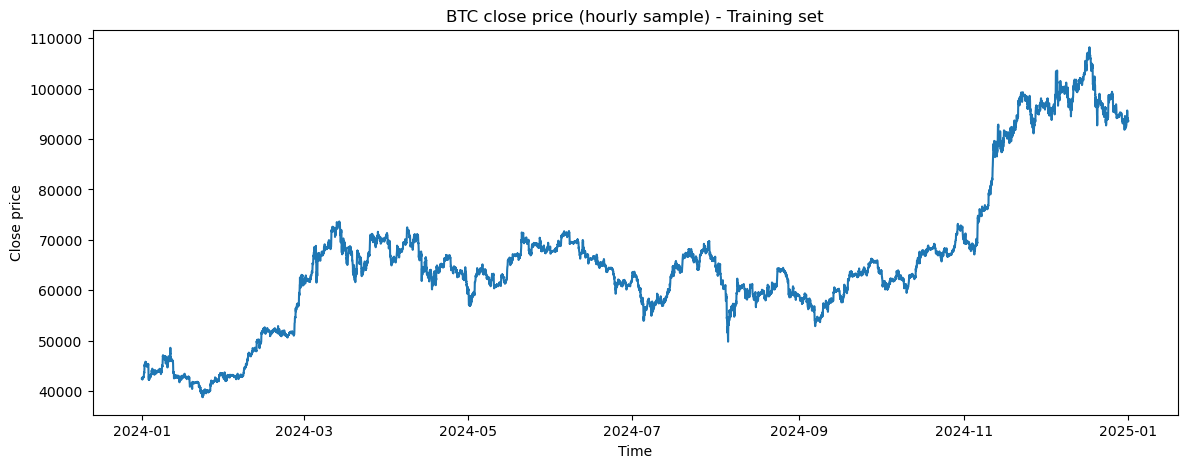

train {'min': 38560.6, 'max': 108225.1, 'mean': 65895.9896058174, 'std': 14688.82571166166}
val {'min': 89290.0, 'max': 109532.6, 'mean': 99951.22037410394, 'std': 4288.854838016126}
test {'min': 74585.8, 'max': 102726.7, 'mean': 88744.32610955056, 'std': 6298.227304853947}


In [5]:
# Visualisation of price trends

# Convert timestamps to datatime
def prepare_time(df):
    df = df.copy()
    df['open_time_dt'] = pd.to_datetime(df['open_time'], unit='ms')
    df = df.set_index('open_time_dt')
    return df

df_train = prepare_time(df_train)
df_val   = prepare_time(df_val)
df_test  = prepare_time(df_test)

# hourly sample for plotting
sample_train = df_train['close'].resample('1H').last()
plt.figure(figsize=(14,5))
plt.plot(sample_train.index, sample_train.values)
plt.title("BTC close price (hourly sample) - Training set")
plt.xlabel("Time")
plt.ylabel("Close price")
plt.show()

# calculate price statistics
for name, df in [("train", df_train), ("val", df_val), ("test", df_test)]:
    stats = {
        "min": float(df['close'].min()),
        "max": float(df['close'].max()),
        "mean": float(df['close'].mean()),
        "std": float(df['close'].std())
    }
    print(name, stats)


## PART B: Feature and label creation

This part essential to create or normalize the data labels. For example, creation of percentages, adding technical indicators, normalizing numerical values, splitting features and labels for model training.

In [6]:
# Technical indicators
def create_features(df):
    df = df.copy()
    for col in ['open','high','low','close','volume']:
        df[col] = pd.to_numeric(df[col], errors='coerce')
    
    # Price-based features
    df['price_range'] = df['high'] - df['low']
    df['price_change'] = df['close'] - df['open']
    df['price_change_pct'] = (df['close'] - df['open']) / df['open'] * 100

    # Moving Averages
    df['ma_5'] = df['close'].rolling(window=5, min_periods=1).mean()
    df['ma_10'] = df['close'].rolling(window=10, min_periods=1).mean()
    df['ma_20'] = df['close'].rolling(window=20, min_periods=1).mean()
    df['ma_50'] = df['close'].rolling(window=50, min_periods=1).mean()

    # MA differences
    df['ma_diff_5_10'] = df['ma_5'] - df['ma_10']
    df['ma_diff_10_20'] = df['ma_10'] - df['ma_20']

    # RSI
    delta = df['close'].diff()
    gain = delta.clip(lower=0).rolling(window=14, min_periods=1).mean()
    loss = -delta.clip(upper=0).rolling(window=14, min_periods=1).mean()
    rs = gain / (loss + 1e-9)
    df['rsi'] = 100 - (100 / (1 + rs))

    # MACD
    exp1 = df['close'].ewm(span=12, adjust=False).mean()
    exp2 = df['close'].ewm(span=26, adjust=False).mean()
    df['macd'] = exp1 - exp2
    df['macd_signal'] = df['macd'].ewm(span=9, adjust=False).mean()
    df['macd_diff'] = df['macd'] - df['macd_signal']

    # Volatility
    df['volatility_10'] = df['close'].rolling(window=10, min_periods=1).std()
    df['volatility_20'] = df['close'].rolling(window=20, min_periods=1).std()

    # Volume features
    df['volume_ma_5'] = df['volume'].rolling(window=5, min_periods=1).mean()
    df['volume_ma_10'] = df['volume'].rolling(window=10, min_periods=1).mean()
    df['volume_ratio'] = df['volume'] / (df['volume_ma_10'] + 1e-9)

    # Momentum
    df['momentum_5'] = df['close'] - df['close'].shift(5)
    df['momentum_10'] = df['close'] - df['close'].shift(10)

    return df

# Apply
print("Creating features for training data ...")
df_train = create_features(df_train)
print("Creating features for validation data ...")
df_val   = create_features(df_val)
print("Creating features for test data ....")
df_test  = create_features(df_test)

print("\nFeatures created successfully!")
print(f"Total number of features: {df_train.shape[1]}")
print("\nNew features: ")
print(df_train.columns.tolist())


Creating features for training data ...
Creating features for validation data ...
Creating features for test data ....

Features created successfully!
Total number of features: 27

New features: 
['open_time', 'open', 'high', 'low', 'close', 'volume', 'close_time', 'price_range', 'price_change', 'price_change_pct', 'ma_5', 'ma_10', 'ma_20', 'ma_50', 'ma_diff_5_10', 'ma_diff_10_20', 'rsi', 'macd', 'macd_signal', 'macd_diff', 'volatility_10', 'volatility_20', 'volume_ma_5', 'volume_ma_10', 'volume_ratio', 'momentum_5', 'momentum_10']


In [7]:
# Create binary classification target (1 if up, 0 if down)
# For each row it will check whether close 30 minutes ahead is greater than current close, since data is 1 minute -- shift by -30

def create_target(df, horizon_minutes=30):
    df = df.copy()
    shift_steps = horizon_minutes  # 1 row = 1 minute
    df['future_close'] = df['close'].shift(-shift_steps)
    df['target'] = (df['future_close'] > df['close']).astype(int)
    return df

df_train = create_target(df_train, 30)
df_val   = create_target(df_val, 30)
df_test  = create_target(df_test, 30)

# Show distribution
for name, df in [("train", df_train), ("val", df_val), ("test", df_test)]:
    print(name, "target distribution:")
    print(df['target'].value_counts(normalize=True))
    print()

train target distribution:
target
1    0.505434
0    0.494566
Name: proportion, dtype: float64

val target distribution:
target
1    0.500762
0    0.499238
Name: proportion, dtype: float64

test target distribution:
target
1    0.50206
0    0.49794
Name: proportion, dtype: float64



Interpretation

- the proportions of 1s and 0s are almost exactly 50-50 in all 3 datasets
- this means the dataset is well-balanced = this helps really good for the model to learn both outcomes equally
- roughly half the time, the price goes up after 30 minutes, and half the time it goes down
    - this is typical for financial time series, that price movements over short horizons often approximaate a random walk

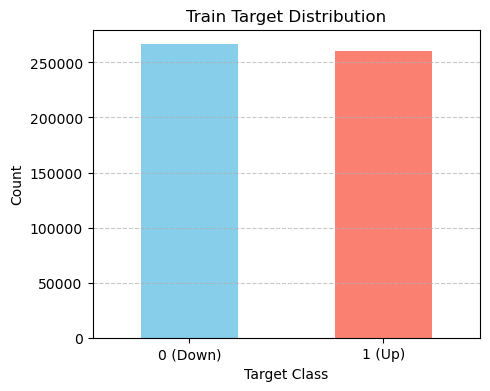

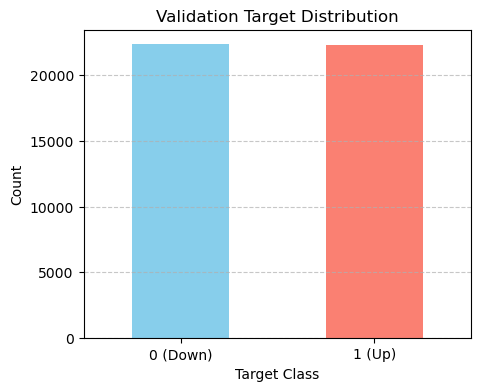

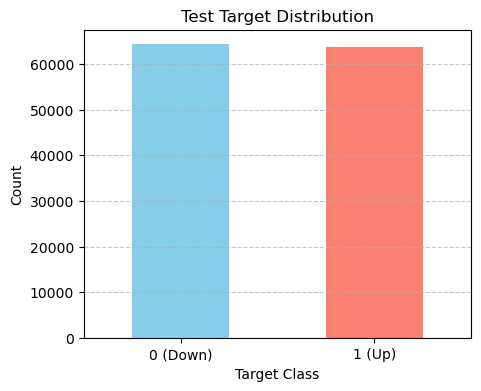

In [8]:
# Visualisation target distribution - count x class

datasets = [("Train", df_train), ("Validation", df_val), ("Test", df_test)]

for name, df in datasets:
    plt.figure(figsize=(5, 4))
    df['target'].value_counts().plot(kind='bar', color=['skyblue', 'salmon'])
    plt.title(f'{name} Target Distribution')
    plt.xlabel('Target Class')
    plt.ylabel('Count')
    plt.xticks(ticks=[0, 1], labels=['0 (Down)', '1 (Up)'], rotation=0)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()


In [9]:
# Prepare final dataset, remove rows with Nan values, define feature columns, create x and y splits

def prepare_X_y(df):
    df = df.copy()
    
    df = df.dropna()
    
    exclude = {'open_time','open_time_dt','open','high','low','close','volume','close_time','future_close','target'}
    feature_cols = [c for c in df.columns if c not in exclude and not c.startswith('Unnamed')]
    X = df[feature_cols].astype(float)
    y = df['target'].astype(int)
    return X, y, feature_cols

X_train, y_train, feature_cols = prepare_X_y(df_train)
X_val, y_val, _ = prepare_X_y(df_val)
X_test, y_test, _ = prepare_X_y(df_test)

print("Number features:", len(feature_cols))
print("Example features:", feature_cols[:20])


Number features: 20
Example features: ['price_range', 'price_change', 'price_change_pct', 'ma_5', 'ma_10', 'ma_20', 'ma_50', 'ma_diff_5_10', 'ma_diff_10_20', 'rsi', 'macd', 'macd_signal', 'macd_diff', 'volatility_10', 'volatility_20', 'volume_ma_5', 'volume_ma_10', 'volume_ratio', 'momentum_5', 'momentum_10']


In [10]:
# Evaluation Function

def evaluate_model(model, X_train, y_train, X_val, y_val, X_test, y_test, name="Model"):
    
    results = {}
    for split, X, y in [("train", X_train, y_train), ("val", X_val, y_val), ("test", X_test, y_test)]:
        preds = model.predict(X)
        acc = accuracy_score(y, preds)
        prec = precision_score(y, preds, zero_division=0)
        rec = recall_score(y, preds, zero_division=0)
        f1 = f1_score(y, preds, zero_division=0)
        results[split] = {"accuracy": acc, "precision": prec, "recall": rec, "f1": f1, "y_true": y, "y_pred": preds}
    
    display(pd.DataFrame({k: {m: v for m, v in vals.items() if m in ['accuracy','precision','recall','f1']} for k, vals in results.items()}))
    
    # Confusion matrices for val and test
    for split in ['val','test']:
        y_true = results[split]['y_true']
        y_pred = results[split]['y_pred']
        cm = confusion_matrix(y_true, y_pred)
        plt.figure(figsize=(4,3))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
        plt.title(f"{name} Confusion Matrix ({split})")
        plt.xlabel("Predicted")
        plt.ylabel("Actual")
        plt.show()
    return results


## PART C: Machine Learning and Deep Learning Models

In this part, 3 ML or DL models will be defined and trained to predict accurate results.

,train,val,test
accuracy,0.639738,0.519013,0.513339
precision,0.638117,0.521535,0.513409
recall,0.663596,0.483396,0.590649
f1,0.650607,0.501742,0.549327


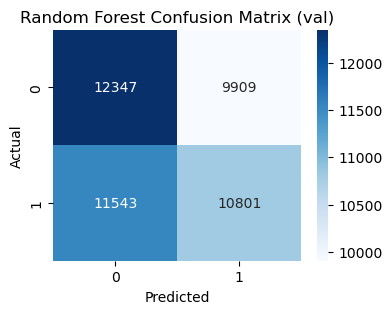

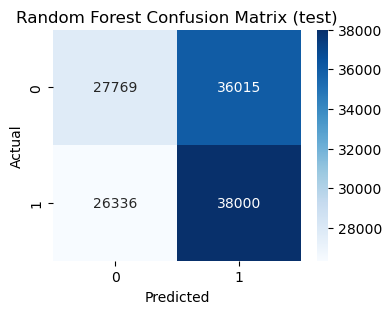

ma_50            0.095384
ma_20            0.085549
ma_5             0.079030
ma_10            0.078929
macd_signal      0.068377
macd             0.058847
volume_ma_10     0.057270
volatility_20    0.053995
volume_ma_5      0.045050
ma_diff_10_20    0.042899
macd_diff        0.042028
volatility_10    0.041861
rsi              0.039896
momentum_10      0.035831
ma_diff_5_10     0.034085
dtype: float64

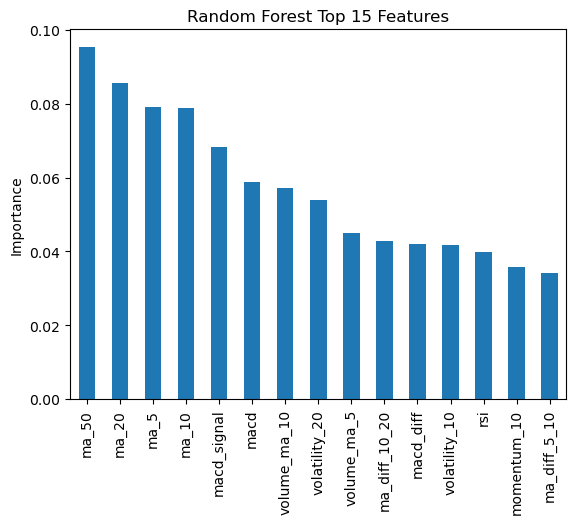

In [11]:
# Random Forest
rf = RandomForestClassifier(n_estimators=100, max_depth=12, n_jobs=-1, random_state=42)
rf.fit(X_train, y_train)

rf_results = evaluate_model(rf, X_train, y_train, X_val, y_val, X_test, y_test, name="Random Forest")

rf_importances = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=False)
rf_top15 = rf_importances.head(15)
display(rf_top15)
rf_top15.plot(kind='bar', title='Random Forest Top 15 Features')
plt.ylabel('Importance')
plt.show()


c:\Users\ragul\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [15:26:11] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\ragul\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [15:26:11] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\ragul\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [15:26:12] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\ragul\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [15:26:12] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtr

Early stopping at iteration 15, best iteration: 5


c:\Users\ragul\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [15:26:22] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,train,val,test
accuracy,0.537226,0.527040,0.510841
precision,0.533984,0.524541,0.510841
recall,0.663513,0.597879,0.609752
f1,0.591743,0.558814,0.555931


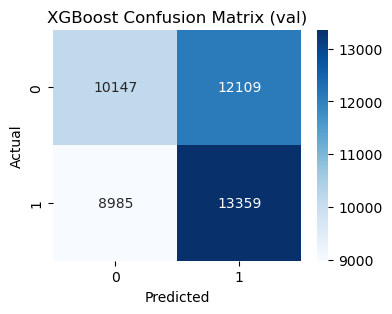

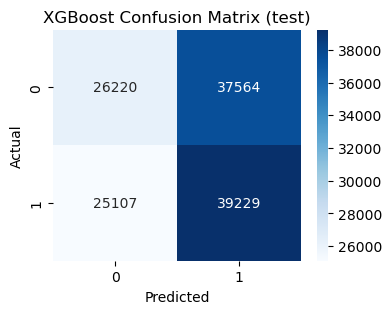

macd                0.221878
macd_signal         0.140165
momentum_5          0.070690
ma_50               0.058212
momentum_10         0.054125
ma_10               0.048675
ma_20               0.045808
price_change_pct    0.040967
ma_5                0.039271
volume_ma_10        0.038340
volatility_20       0.038212
rsi                 0.030257
volatility_10       0.029159
volume_ma_5         0.025544
macd_diff           0.023322
dtype: float32

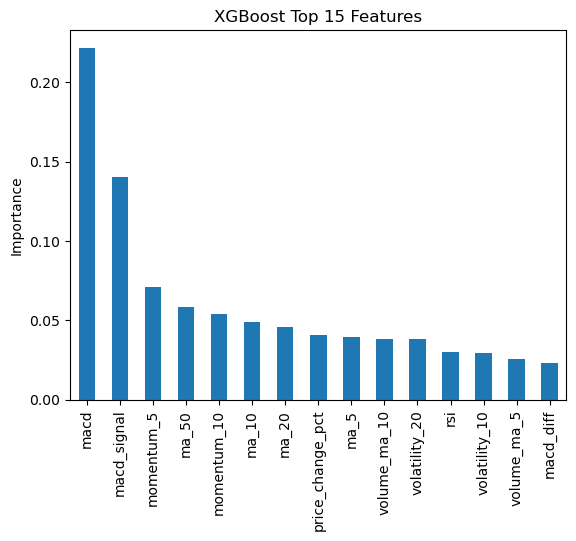

In [12]:
# XGBoost
xgb_clf = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)

# Manual early stopping because my computer doesnt allow the newest version of XGB
best_val_score = 0
best_iteration = 0
for i in range(1, xgb_clf.n_estimators + 1):
    xgb_clf.n_estimators = i 
    xgb_clf.fit(X_train, y_train, verbose=False)
    
    y_val_pred = xgb_clf.predict(X_val)
    val_score = accuracy_score(y_val, y_val_pred)
    
    if val_score > best_val_score:
        best_val_score = val_score
        best_iteration = i
    elif i - best_iteration >= 10:  # stop if no improvement for 10 iterations
        print(f"Early stopping at iteration {i}, best iteration: {best_iteration}")
        break


xgb_clf.n_estimators = best_iteration
xgb_clf.fit(X_train, y_train, verbose=False)

# Evaluate mode
xgb_results = evaluate_model(xgb_clf, X_train, y_train, X_val, y_val, X_test, y_test, name="XGBoost")

# Features
xgb_importances = pd.Series(xgb_clf.feature_importances_, index=feature_cols).sort_values(ascending=False)
xgb_top15 = xgb_importances.head(15)
display(xgb_top15)
xgb_top15.plot(kind='bar', title='XGBoost Top 15 Features')
plt.ylabel('Importance')
plt.show()

In [13]:
# Custom Deep Learning Model: CNN and LSTM Hybrid

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, LSTM, Conv1D, MaxPooling1D, Flatten
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.preprocessing import StandardScaler

# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

# Reshape for CNN/LSTM: samples, timesteps, features
# timesteps = 1 
X_train_dl = np.expand_dims(X_train_scaled, axis=1)
X_val_dl   = np.expand_dims(X_val_scaled, axis=1)
X_test_dl  = np.expand_dims(X_test_scaled, axis=1)

print("Deep learning input shape:", X_train_dl.shape)



Deep learning input shape: (527000, 1, 20)


In [14]:
# build model

def build_cnn_lstm_model(input_shape):
    model = Sequential()
    
    # CNN layer: captures local feature relationships
    model.add(Conv1D(filters=64, kernel_size=1, activation='relu', input_shape=input_shape))
    model.add(MaxPooling1D(pool_size=1))
    
    # LSTM layer: captures temporal dependencies
    model.add(LSTM(64, return_sequences=False))
    
    # Regularization
    model.add(Dropout(0.3))
    
    # Fully connected layers
    model.add(Dense(64, activation='relu'))
    model.add(Dropout(0.2))
    
    # Output layer 
    model.add(Dense(1, activation='sigmoid'))
    
    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    
    return model


input_shape = (X_train_dl.shape[1], X_train_dl.shape[2])
cnn_lstm_model = build_cnn_lstm_model(input_shape)
cnn_lstm_model.summary()


c:\Users\ragul\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 1, 64)          │         1,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 1, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 38,593 (150.75 KB)

 Trainable params: 38,593 (150.75 KB)

 Non-trainable params: 0 (0.00 B)

In [15]:
# Early stopping for my own computer

early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

history = cnn_lstm_model.fit(
    X_train_dl, y_train,
    validation_data=(X_val_dl, y_val),
    epochs=10,
    batch_size=512,
    callbacks=[early_stop],
    verbose=1
)


Epoch 1/10
1030/1030 ━━━━━━━━━━━━━━━━━━━━ 18s 11ms/step - accuracy: 0.5187 - loss: 0.6920 - val_accuracy: 0.5313 - val_loss: 0.6906
Epoch 2/10
1030/1030 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - accuracy: 0.5218 - loss: 0.6915 - val_accuracy: 0.5309 - val_loss: 0.6905
Epoch 3/10
1030/1030 ━━━━━━━━━━━━━━━━━━━━ 11s 11ms/step - accuracy: 0.5229 - loss: 0.6914 - val_accuracy: 0.5278 - val_loss: 0.6912
Epoch 4/10
1030/1030 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - accuracy: 0.5244 - loss: 0.6911 - val_accuracy: 0.5245 - val_loss: 0.6914
Epoch 5/10
1030/1030 ━━━━━━━━━━━━━━━━━━━━ 19s 8ms/step - accuracy: 0.5250 - loss: 0.6909 - val_accuracy: 0.5281 - val_loss: 0.6905


16469/16469 ━━━━━━━━━━━━━━━━━━━━ 55s 3ms/step
1394/1394 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
4004/4004 ━━━━━━━━━━━━━━━━━━━━ 4s 985us/step


,train,val,test
accuracy,0.524283,0.530874,0.510459
precision,0.523894,0.531093,0.511824
recall,0.645160,0.543144,0.543646
f1,0.578237,0.537051,0.527255


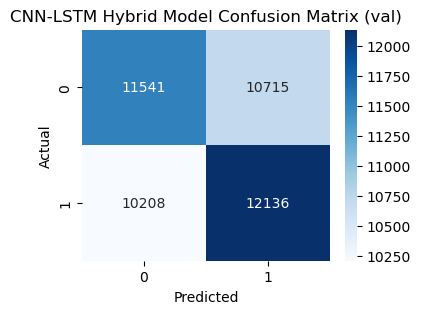

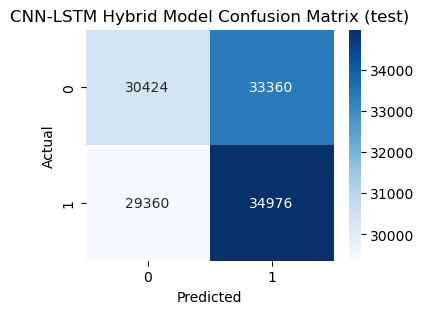

In [16]:
# Evaluate model

def evaluate_dl_model(model, X_train, y_train, X_val, y_val, X_test, y_test, name="Deep Model"):
    results = {}
    for split, X, y in [("train", X_train, y_train), ("val", X_val, y_val), ("test", X_test, y_test)]:
        preds = (model.predict(X) > 0.5).astype(int).flatten()
        acc = accuracy_score(y, preds)
        prec = precision_score(y, preds, zero_division=0)
        rec = recall_score(y, preds, zero_division=0)
        f1 = f1_score(y, preds, zero_division=0)
        results[split] = {"accuracy": acc, "precision": prec, "recall": rec, "f1": f1, "y_true": y, "y_pred": preds}

    display(pd.DataFrame({k: {m: v for m, v in vals.items() if m in ['accuracy','precision','recall','f1']} for k, vals in results.items()}))
    
    # Confusion matrices
    for split in ['val', 'test']:
        cm = confusion_matrix(results[split]['y_true'], results[split]['y_pred'])
        plt.figure(figsize=(4,3))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
        plt.title(f"{name} Confusion Matrix ({split})")
        plt.xlabel("Predicted")
        plt.ylabel("Actual")
        plt.show()
    
    return results


cnn_lstm_results = evaluate_dl_model(cnn_lstm_model, X_train_dl, y_train, X_val_dl, y_val, X_test_dl, y_test, name="CNN-LSTM Hybrid Model")


## PART D: Evaluation metrics and plots

This section compares the performance of the three models: Random Forest, XGBoost, custom CNN-LSTM hybrid deep learning model. Evaluation metrics are reported on the test dataset - accuracy, precision, recall, F1-score

In [17]:
# Collect all results into one dictionary
all_results = {
    "Random Forest": rf_results,      
    "XGBoost": xgb_results,           
    "CNN-LSTM Hybrid": cnn_lstm_results 
}

# A summary table
summary = []
for name, results in all_results.items():
    test_metrics = results['test']
    summary.append({
        "Model": name,
        "Accuracy": test_metrics['accuracy'],
        "Precision": test_metrics['precision'],
        "Recall": test_metrics['recall'],
        "F1": test_metrics['f1']
    })

df_summary = pd.DataFrame(summary)
display(df_summary.sort_values(by="F1", ascending=False).reset_index(drop=True))

,Model,Accuracy,Precision,Recall,F1
0,XGBoost,0.510841,0.510841,0.609752,0.555931
1,Random Forest,0.513339,0.513409,0.590649,0.549327
2,CNN-LSTM Hybrid,0.510459,0.511824,0.543646,0.527255


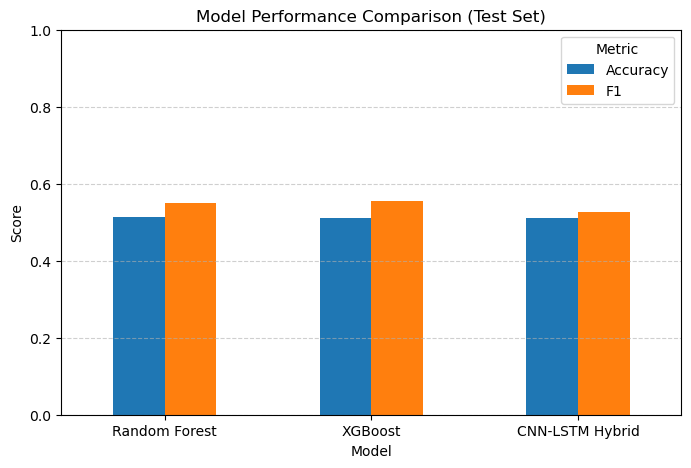

In [18]:
# Bar plot comparison
plt.figure(figsize=(8,5))
df_summary.set_index("Model")[["Accuracy","F1"]].plot(kind="bar", ax=plt.gca())
plt.title("Model Performance Comparison (Test Set)")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.xticks(rotation=0)
plt.legend(title="Metric")
plt.show()

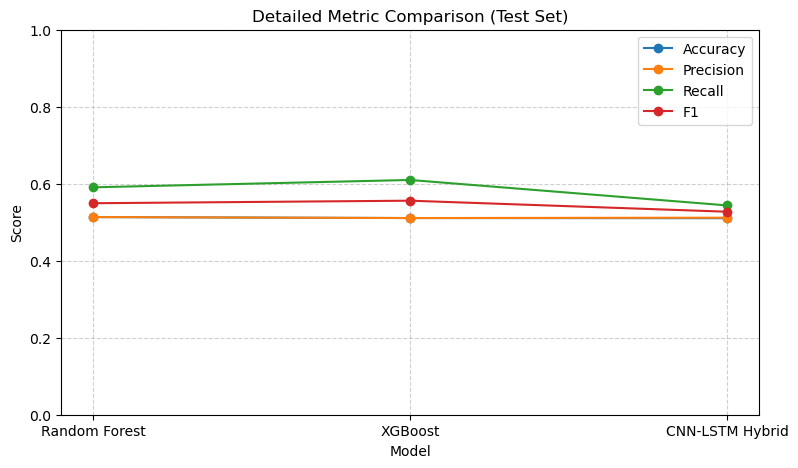

In [19]:
# Visualisation of precision, recall, f1
df_melted = df_summary.melt(id_vars="Model", var_name="Metric", value_name="Score")
plt.figure(figsize=(9,5))
for metric in ["Accuracy", "Precision", "Recall", "F1"]:
    subset = df_melted[df_melted["Metric"] == metric]
    plt.plot(subset["Model"], subset["Score"], marker='o', label=metric)

plt.title("Detailed Metric Comparison (Test Set)")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

## Results and Evaluation

**1. Which model performed best overall?**

Overall the model that performed the best across the validation is XGBoost. It has achieved the highest validation F1 score and test F1 score with highest recall. Although all models achieved similar accuracies (51-52%), XGBoost showed better balance between precision and recall, suggesting a stronger generalization ability compared to Random Forest and CNN-LSTM hybrid model.


**2. Are there signs of overfitting?**

There were no strong signs of overfitting in any of the models. The differences between training and test accuracies were relatively small. This is suggesting that the models did not memorize the training data. 
The overalll low performance indicates that the models may be underffiting the complex dynamics - they failed to capture enough predictive patterns from the limited feature set.

**3. How do models compare to baseline?**

The models performed slightly above baseline, this would achieve roughly 50% accuracy. Achieving 51-52% accuracy shows that the models learned some useful information from the data, but the margin over random guessing is small. This highlights the difficulty of short-term financial prediction using only price and volume data.

**4. What are the limitations of real-world trading?**

- Transaction costs and fees - even tiny costs per trade can quickly erase the small accuracy advantage shown by the models.
- Market volatility and slippage - actual execution prices often differ from predicted prices, reducing potential profit.
- Latency and data delays - high-frequency price changes can invalidate predictions made even a few seconds earlier.
- Non-stationarity - market behaviour changes constantly. Models trained on past data may fail when new market conditions arise.
- Data leakage and hindsight bias - using future-influenced features can make the model unrealistically good during training but useless live.
- Risk management - accuracy alone ignores drawdowns, risk exposure, and position sizing. These are essential for trading strategies.

Overall, even a model with 55 % accuracy may not be profitable once these factors are included.

**5. What additional factors should be considered?**

- Market sentiment (news headlines, Twitter/X sentiment, Reddit discussions).
- Macro-economic variables (interest rates, inflation, global indices).
- Blockchain-specific metrics (on-chain transaction volume, active addresses).
- Liquidity and order-book depth (measures of market activity and imbalance).
- Incorporating these additional data sources could capture factors driving crypto price moves that pure technical indicators miss.

**6. 2 ways to improve model performance**

- Enhance feature engineering and temporal context: add lagged returns, rolling volatility ratios, and indicators from multiple time horizons. It can also include cross-asset or sentiment features to provide broader market context.
- Improve model tuning and validation strategy: use time-series-aware cross-validation and apply hyperparameter optimisation. Additionally, balance the dataset or adjust class weights to handle potential class imbalance.